In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_noisy = pd.read_csv('train.csv', header=None).values.astype(np.float32)
test_noisy = pd.read_csv('test.csv', header=None).values.astype(np.float32)
train_clean = pd.read_csv('etalon_for_train.csv', header=None).values.astype(np.float32)
test_clean = pd.read_csv('etalon_for_test.csv', header=None).values.astype(np.float32)

print(f"Размер train_data: {train_noisy.shape}")
print(f"Размер test_data: {test_noisy.shape}")

print(f"Размер etalon_train: {train_clean.shape}")
print(f"Размер etalon_test: {test_clean.shape}")

Размер train_data: (1000, 5000)
Размер test_data: (500, 5000)
Размер etalon_train: (1000, 5000)
Размер etalon_test: (500, 5000)


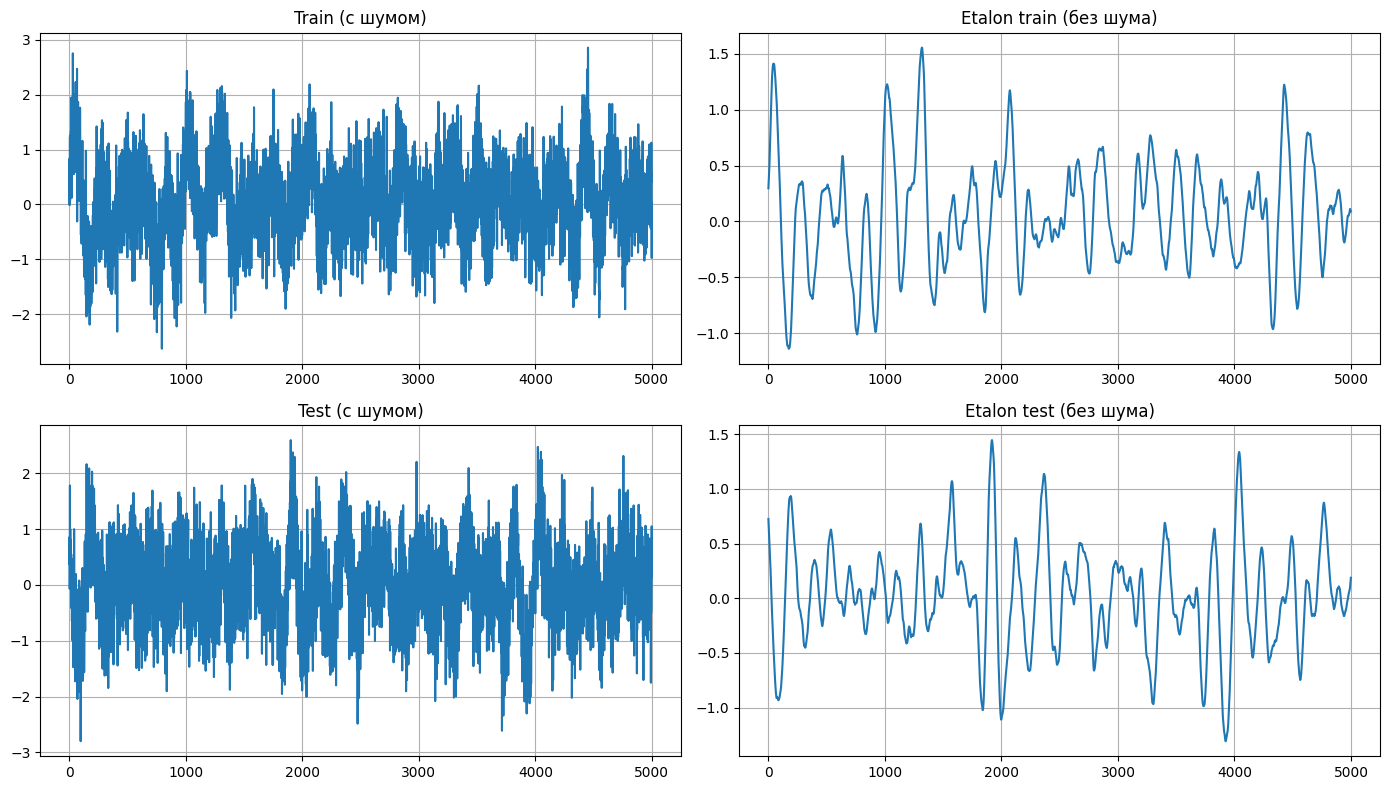

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(train_noisy[0])
axes[0, 0].set_title('Train (с шумом)')
axes[0, 0].grid(True)

axes[0, 1].plot(train_clean[0])
axes[0, 1].set_title('Etalon train (без шума)')
axes[0, 1].grid(True)

axes[1, 0].plot(test_noisy[0])
axes[1, 0].set_title('Test (с шумом)')
axes[1, 0].grid(True)

axes[1, 1].plot(test_clean[0])
axes[1, 1].set_title('Etalon test (без шума)')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
DT = 0.05
PAST_SECONDS = 200
FUTURE_SECONDS = 50

N_INPUT = int(PAST_SECONDS / DT)
N_OUTPUT = int(FUTURE_SECONDS / DT)

HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 32
EPOCHS = 1000
LEARNING_RATE = 0.001

In [13]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # Берем последний выход LSTM
        last_output = lstm_out[:, -1, :]
        out = self.fc(self.dropout(last_output))
        return out

In [14]:
X_train = train_noisy[:, :N_INPUT]
Y_train = train_clean[:, N_INPUT : N_INPUT + N_OUTPUT]

X_test = test_noisy[:, :N_INPUT]
Y_true = test_clean[:, N_INPUT : N_INPUT + N_OUTPUT]

In [15]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)


X_train_tensor = torch.FloatTensor(X_train_scaled).unsqueeze(-1)
Y_train_tensor = torch.FloatTensor(Y_train_scaled)           

X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(-1)   

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

model = LSTMForecaster(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=N_OUTPUT,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

Используемое устройство: cuda


In [17]:
best_loss = float('inf')
patience_counter = 0
max_patience = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_Y in train_loader:
        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)
        
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_Y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        X_test_dev = X_test_tensor.to(device)
        Y_pred_dev = model(X_test_dev)
        val_loss = criterion(Y_pred_dev, torch.FloatTensor(Y_train_scaled).to(device)[:Y_pred_dev.shape[0]])
        val_losses.append(val_loss.item())
    
    scheduler.step(avg_train_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss.item():.6f}")
    
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_lstm_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= max_patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

Epoch 10/1000, Train Loss: 0.949254, Val Loss: 1.041942
Epoch 20/1000, Train Loss: 0.934856, Val Loss: 1.077717
Epoch 30/1000, Train Loss: 0.929285, Val Loss: 1.062523
Epoch 40/1000, Train Loss: 0.924457, Val Loss: 1.049916
Epoch 50/1000, Train Loss: 0.910259, Val Loss: 1.080858
Epoch 60/1000, Train Loss: 0.894887, Val Loss: 1.077961
Epoch 70/1000, Train Loss: 0.866036, Val Loss: 1.085280
Epoch 80/1000, Train Loss: 0.805645, Val Loss: 1.151773
Epoch 90/1000, Train Loss: 0.705481, Val Loss: 1.196353
Epoch 100/1000, Train Loss: 0.631781, Val Loss: 1.269858
Epoch 110/1000, Train Loss: 0.569572, Val Loss: 1.310089
Epoch 120/1000, Train Loss: 0.501235, Val Loss: 1.325240
Epoch 130/1000, Train Loss: 0.451330, Val Loss: 1.380623
Epoch 140/1000, Train Loss: 0.422964, Val Loss: 1.379931
Epoch 150/1000, Train Loss: 0.387397, Val Loss: 1.395872
Epoch 160/1000, Train Loss: 0.356420, Val Loss: 1.398101
Epoch 170/1000, Train Loss: 0.332532, Val Loss: 1.420197
Epoch 180/1000, Train Loss: 0.315039, Va

In [18]:
model.load_state_dict(torch.load('best_lstm_model.pth'))

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    Y_pred_scaled = model(X_test_tensor).cpu().numpy()

Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)

In [19]:
L = Y_true.shape[0]
mean_error = np.zeros(N_OUTPUT)
rms_error = np.zeros(N_OUTPUT)

for t in range(N_OUTPUT):
    diff = Y_pred[:, t] - Y_true[:, t]
    mean_error[t] = np.mean(diff)
    rms_error[t] = np.sqrt(np.sum((diff - mean_error[t])**2) / (L - 1))

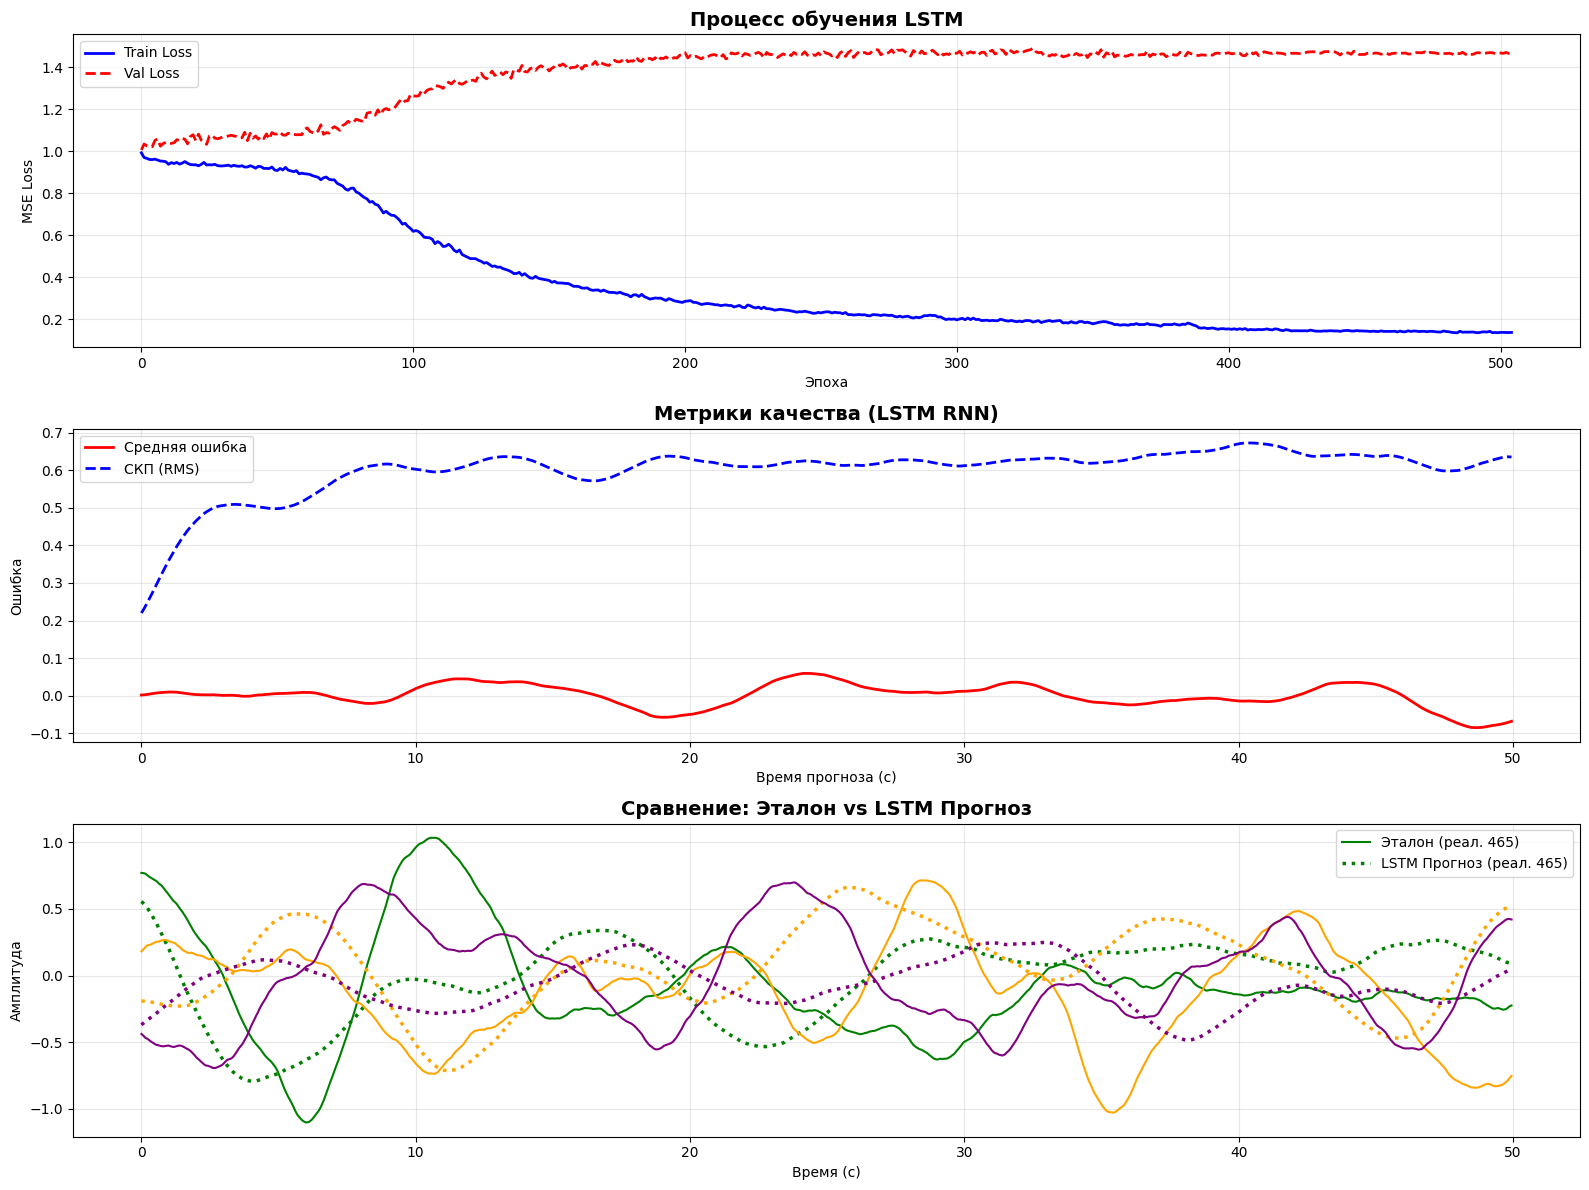

In [20]:
time_axis = np.arange(N_OUTPUT) * DT

plt.figure(figsize=(16, 12))

plt.subplot(3, 1, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='red', linewidth=2, linestyle='--')
plt.title('Процесс обучения LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time_axis, mean_error, label='Средняя ошибка', color='red', linewidth=2)
plt.plot(time_axis, rms_error, label='СКП (RMS)', color='blue', linewidth=2, linestyle='--')
plt.title(f'Метрики качества (LSTM RNN)', fontsize=14, fontweight='bold')
plt.xlabel('Время прогноза (с)')
plt.ylabel('Ошибка')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(3, 1, 3)
sample_indices = np.random.choice(L, 3, replace=False)
colors = ['green', 'orange', 'purple']

for i, idx in enumerate(sample_indices):
    plt.plot(time_axis, Y_true[idx], color=colors[i], linestyle='-', linewidth=1.5, 
             label=f'Эталон (реал. {idx})' if i==0 else "")
    plt.plot(time_axis, Y_pred[idx], color=colors[i], linestyle=':', linewidth=2.5, 
             label=f'LSTM Прогноз (реал. {idx})' if i==0 else "")

plt.title('Сравнение: Эталон vs LSTM Прогноз', fontsize=14, fontweight='bold')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [21]:
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (t=50c):")
print("="*60)
print(f"LSTM RNN СКП:         {rms_error[-1]:.6f}")
print(f"LSTM RNN Средняя ошибка: {mean_error[-1]:.6f}")
print("="*60)


ИТОГОВЫЕ РЕЗУЛЬТАТЫ (t=50c):
LSTM RNN СКП:         0.635406
LSTM RNN Средняя ошибка: -0.068163
